## Infos
- Implement Wandb
- Feature engineering:
    - **lags**: y(t−1), y(t−2), y(t−24), y(t−168) (hour/day/week patterns)
    - **difference features**: y(t)−y(t−1), y(t)−y(t−24) etc.
    - **rolling stats**: mean / std / min / max / slope of last 6h / 24h / 7d
    - **volatility/stability**: rolling std, MAD, coefficient of variation
    - **time-of-use effects**: weekend flag, maybe holidays, sin/cos encoding of time of year (cyclic)
    - **external drivers**: make use of causal context (like temperature, humidity, solar irradiance)
    - **reduce data**: remove night timestamps, due to DR-flags = 0
- Improve training
    - gradient clipping
    - early stopping
    - warmup
    - dropout
    - weight decay
    - checkpoints

- TCN remove "causal flag" (something causal dilation..)
    - set causal = False for leakage from future (needed for accuracy)

Questions:
- Does it make sense to also consider "future" data?
    - Makes sense as long as the real-use case also includes both

Install all necessary libraries.

In [1]:
%pip install torch
%pip install pandas
%pip install numpy
%pip install imblearn
%pip install scikit-learn
%pip install matplotlib
%pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu129
%pip install wandb
%pip install holidays

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


...


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Import all necessary libraries.

In [2]:
import pandas as pd
import numpy as np
import os
import wandb
import datetime
import random
import holidays
import torch
import torch.nn as nn
from torch.nn.utils import clip_grad_norm_
from torch.utils.data import Dataset, DataLoader
from imblearn.metrics import geometric_mean_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, f1_score, root_mean_squared_error
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

import sys
sys.path.append('../src/evaluation')

from comp_metrics import evaluate_all_metrics

c:\Github_FabianDubach\aicomp-flextrack\.venv\Lib\site-packages\pydantic\_internal\_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
c:\Github_FabianDubach\aicomp-flextrack\.venv\Lib\site-packages\pydantic\_internal\_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened bec

In [3]:
os.environ["WANDB_API_KEY"] = "3aaf9f796df65417b3f5f8560b43875171b55805"

In [4]:
wandb.login()

wandb: Currently logged in as: fabian-dubach (fabian-dubach-hochschule-luzern) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

Set seed for reproducibility.

In [5]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [6]:
df_train = pd.read_csv("../data/regression/regression-train.csv")
df_test = pd.read_csv("../data/regression/regression-test.csv")

In [7]:
print(f"Dataset shape: {df_train.shape}")
print(f"\nColumns: {df_train.columns.tolist()}")

Dataset shape: (105120, 7)

Columns: ['Site', 'Timestamp_Local', 'Dry_Bulb_Temperature_C', 'Global_Horizontal_Radiation_W/m2', 'Building_Power_kW', 'Demand_Response_Flag', 'Demand_Response_Capacity_kW']


In [8]:
df_train.head()

,Site,Timestamp_Local,Dry_Bulb_Temperature_C,Global_Horizontal_Radiation_W/m2,Building_Power_kW,Demand_Response_Flag,Demand_Response_Capacity_kW
0,siteA,2019-01-01 00:00:00,22.20,0.0,4.8,0,0.0
1,siteA,2019-01-01 00:15:00,22.27,0.0,4.8,0,0.0
2,siteA,2019-01-01 00:30:00,22.35,0.0,4.8,0,0.0
3,siteA,2019-01-01 00:45:00,22.42,0.0,4.8,0,0.0
4,siteA,2019-01-01 01:00:00,22.50,0.0,4.8,0,0.0


# Feature Engineering

## Temporal Components

`hour_of_day`

**Best**: encode as cyclic using sine/cosine (captures continuity between 23→0).
`sin_hour = sin(2π * hour / 24)`, `cos_hour = cos(2π * hour / 24)`.

**Optional**: also include a small set of one-hot bins like is_night, is_business_hours if behavior is strongly segmented.

**Why**: One-hot loses the notion that 23:00 and 0:00 are adjacent.

**WARNING!**: Cyclic may not be the best option in our usecase, as we remove some timestamps per day to only keep relevant data

`day_of_week` (0–6)

Good candidate for one-hot (7 categories).

**Alternative**: cyclic encoding (sine/cos) if you prefer continuous representation; or both (OHE + cyc) if model benefits.

**Recommendation**: OHE is fine for most models and interpretable.

`day_of_month` (1–31)

Usually NOT good for one-hot — 31 columns adds complexity and many values behave similarly.

**Better**:

use `day_of_month` as numeric (may be noisy),

or derive features: `is_month_start`, `is_month_end`, `week_of_month`, `day_bucket` (e.g., 1–7, 8–14, ...),

or cyclic encode `day_of_month` if you think monthly periodicity matters (but monthly patterns often weak).

`day_of_year` / `month`

**Month (1–12)**: one-hot is fine (12 categories) or cyclic encoding (seasonality).

**Day_of_year (1–365)**: use Fourier terms (multiple sine/cos pairs) to model seasonal cycles rather than 365 OHE columns.

`is_weekend`, `is_holiday`

**One-hot / binary** — very useful. If holiday types matter, create `holiday_type` and consider OHE (low cardinality).

In [9]:
australian_holidays = holidays.AU()

def add_time_features(df):
    df['Timestamp_Local'] = pd.to_datetime(df['Timestamp_Local']) # dont use in input (feature)
    df['hour'] = df['Timestamp_Local'].dt.hour # normally cyclic, doesn't make sense if we remove night data
    df['minute'] = df['Timestamp_Local'].dt.minute # OHE
    # df['day_of_month'] = df['Timestamp_Local'].dt.day # remove for now, but maybe check in future for performance
    # df['day_of_year'] = df['Timestamp_Local'].dt.dayofyear # remove for now, but maybe check in future for performance
    df['month'] = df['Timestamp_Local'].dt.month # cyclic
    df['day_of_week'] = df['Timestamp_Local'].dt.dayofweek # OHE
    df['is_weekend'] = df['Timestamp_Local'].dt.dayofweek >= 5
    df['is_holiday'] = df['Timestamp_Local'].dt.date.apply(lambda x: x in australian_holidays)
    return df

In [10]:
df_train = add_time_features(df_train)

In [11]:
df_train.head()

,Site,Timestamp_Local,Dry_Bulb_Temperature_C,Global_Horizontal_Radiation_W/m2,Building_Power_kW,Demand_Response_Flag,Demand_Response_Capacity_kW,hour,minute,month,day_of_week,is_weekend,is_holiday
0,siteA,2019-01-01 00:00:00,22.20,0.0,4.8,0,0.0,0,0,1,1,False,True
1,siteA,2019-01-01 00:15:00,22.27,0.0,4.8,0,0.0,0,15,1,1,False,True
2,siteA,2019-01-01 00:30:00,22.35,0.0,4.8,0,0.0,0,30,1,1,False,True
3,siteA,2019-01-01 00:45:00,22.42,0.0,4.8,0,0.0,0,45,1,1,False,True
4,siteA,2019-01-01 01:00:00,22.50,0.0,4.8,0,0.0,1,0,1,1,False,True


### Remove Entries over Night

Previous data analysis has shown, that data over night is constant and never part of any DR events

Hour values are now from 6 AM to 7 PM, will be normalized later by scalar.

In [12]:
df_train = df_train[
    ((df_train['hour'] > 6) & (df_train['hour'] < 19)) |
    ((df_train['hour'] == 6) & (df_train['minute'] >= 0)) |
    ((df_train['hour'] == 19) & (df_train['minute'] == 0))
].copy()

In [13]:
ENTRIES_PER_DAY = 53  # 15 min intervals from 6:00 to 19:00

### Cyclic Encoding

In [14]:
df_train['month_sin'] = np.sin(2 * np.pi * (df_train['month'] / 12))
df_train['month_cos'] = np.cos(2 * np.pi * (df_train['month'] / 12))

In [15]:
df_train.columns

Index(['Site', 'Timestamp_Local', 'Dry_Bulb_Temperature_C',
       'Global_Horizontal_Radiation_W/m2', 'Building_Power_kW',
       'Demand_Response_Flag', 'Demand_Response_Capacity_kW', 'hour', 'minute',
       'month', 'day_of_week', 'is_weekend', 'is_holiday', 'month_sin',
       'month_cos'],
      dtype='object')

In [16]:
df_train.drop(columns=['month'], inplace=True)

In [17]:
df_train.columns

Index(['Site', 'Timestamp_Local', 'Dry_Bulb_Temperature_C',
       'Global_Horizontal_Radiation_W/m2', 'Building_Power_kW',
       'Demand_Response_Flag', 'Demand_Response_Capacity_kW', 'hour', 'minute',
       'day_of_week', 'is_weekend', 'is_holiday', 'month_sin', 'month_cos'],
      dtype='object')

## Lag

Lags within the sequence length for RNNs are not necessary, due to the fact that the sliding window already provides the previous values.

In [18]:
# df_train['Building_Power_kW_lag_1h'] = (df_train.groupby('Site')['Building_Power_kW'].shift(4))
# df_train['Building_Power_kW_lag_1d'] = (df_train.groupby('Site')['Building_Power_kW'].shift(ENTRIES_PER_DAY))

In [19]:
# df_train['Dry_Bulb_Temperature_C_lag_1h'] = (df_train.groupby('Site')['Dry_Bulb_Temperature_C'].shift(4))
# df_train['Dry_Bulb_Temperature_C_lag_1d'] = (df_train.groupby('Site')['Dry_Bulb_Temperature_C'].shift(ENTRIES_PER_DAY))

# df_train['Global_Horizontal_Radiation_W/m2_lag_1h'] = (df_train.groupby('Site')['Global_Horizontal_Radiation_W/m2'].shift(4))
# df_train['Global_Horizontal_Radiation_W/m2_lag_1d'] = (df_train.groupby('Site')['Global_Horizontal_Radiation_W/m2'].shift(ENTRIES_PER_DAY))

In [20]:
# df_train['Demand_Response_Flag_lag_1h'] = (df_train.groupby('Site')['Demand_Response_Flag'].shift(4))
# df_train['Demand_Response_Flag_lag_1d'] = (df_train.groupby('Site')['Demand_Response_Flag'].shift(ENTRIES_PER_DAY))

## Difference Feature

In [21]:
df_train['Building_Power_kW_diff_15min'] = (df_train.groupby('Site')['Building_Power_kW'].diff(1))
df_train['Building_Power_kW_diff_1h'] = (df_train.groupby('Site')['Building_Power_kW'].diff(4))
df_train['Building_Power_kW_diff_1d'] = (df_train.groupby('Site')['Building_Power_kW'].diff(ENTRIES_PER_DAY))

In [22]:
df_train['Dry_Bulb_Temperature_C_diff_15min'] = (df_train.groupby('Site')['Dry_Bulb_Temperature_C'].diff(1))
df_train['Global_Horizontal_Radiation_W/m2_diff_15min'] = (df_train.groupby('Site')['Global_Horizontal_Radiation_W/m2'].diff(1))

## Rolling Statistics

In [23]:
group = df_train.groupby('Site')['Building_Power_kW']

df_train['Building_Power_kW_rolling_mean_1h'] = group.rolling(4).mean().reset_index(level=0, drop=True)
df_train['Building_Power_kW_rolling_mean_2h'] = group.rolling(8).mean().reset_index(level=0, drop=True)
df_train['Building_Power_kW_rolling_mean_1d'] = group.rolling(ENTRIES_PER_DAY).mean().reset_index(level=0, drop=True)

df_train['Building_Power_kW_rolling_std_1h'] = group.rolling(4).std().reset_index(level=0, drop=True)
df_train['Building_Power_kW_rolling_std_2h'] = group.rolling(8).std().reset_index(level=0, drop=True)
df_train['Building_Power_kW_rolling_std_1d'] = group.rolling(ENTRIES_PER_DAY).std().reset_index(level=0, drop=True)

df_train['Building_Power_kW_rolling_min_1h'] = group.rolling(4).min().reset_index(level=0, drop=True)
df_train['Building_Power_kW_rolling_min_2h'] = group.rolling(8).min().reset_index(level=0, drop=True)

df_train['Building_Power_kW_rolling_max_1h'] = group.rolling(4).max().reset_index(level=0, drop=True)
df_train['Building_Power_kW_rolling_max_2h'] = group.rolling(8).max().reset_index(level=0, drop=True)


## One-Hot Encodings

In [24]:
df_train = pd.get_dummies(df_train, columns=['minute', 'day_of_week'])

In [25]:
df_train = pd.get_dummies(df_train, columns=['Demand_Response_Flag'])
# df_train = pd.get_dummies(df_train, columns=['Demand_Response_Flag', 'Demand_Response_Flag_lag_1h', 'Demand_Response_Flag_lag_1d']) # If lag features are used

In [26]:
df_train['is_holiday'] = df_train['is_holiday'].astype(int)
df_train['is_weekend'] = df_train['is_weekend'].astype(int)

# Split Feature Columns

In [27]:
df_train.columns

Index(['Site', 'Timestamp_Local', 'Dry_Bulb_Temperature_C',
       'Global_Horizontal_Radiation_W/m2', 'Building_Power_kW',
       'Demand_Response_Capacity_kW', 'hour', 'is_weekend', 'is_holiday',
       'month_sin', 'month_cos', 'Building_Power_kW_diff_15min',
       'Building_Power_kW_diff_1h', 'Building_Power_kW_diff_1d',
       'Dry_Bulb_Temperature_C_diff_15min',
       'Global_Horizontal_Radiation_W/m2_diff_15min',
       'Building_Power_kW_rolling_mean_1h',
       'Building_Power_kW_rolling_mean_2h',
       'Building_Power_kW_rolling_mean_1d', 'Building_Power_kW_rolling_std_1h',
       'Building_Power_kW_rolling_std_2h', 'Building_Power_kW_rolling_std_1d',
       'Building_Power_kW_rolling_min_1h', 'Building_Power_kW_rolling_min_2h',
       'Building_Power_kW_rolling_max_1h', 'Building_Power_kW_rolling_max_2h',
       'minute_0', 'minute_15', 'minute_30', 'minute_45', 'day_of_week_0',
       'day_of_week_1', 'day_of_week_2', 'day_of_week_3', 'day_of_week_4',
       'day_of_week

In [28]:
# HINT: dont use site as a feature (only to calculate other features based on past timestamps)

continuous_feature_columns = ['Dry_Bulb_Temperature_C', 'Global_Horizontal_Radiation_W/m2', 'Building_Power_kW',
                              'Building_Power_kW_diff_15min', 'Building_Power_kW_diff_1h', 'Building_Power_kW_diff_1d', 
                              'Dry_Bulb_Temperature_C_diff_15min', 'Global_Horizontal_Radiation_W/m2_diff_15min',
                              'Building_Power_kW_rolling_mean_1h', 'Building_Power_kW_rolling_mean_2h', 'Building_Power_kW_rolling_mean_1d',
                              'Building_Power_kW_rolling_std_1h', 'Building_Power_kW_rolling_std_2h', 'Building_Power_kW_rolling_std_1d',
                              'Building_Power_kW_rolling_min_1h', 'Building_Power_kW_rolling_min_2h', 'Building_Power_kW_rolling_max_1h', 
                              'Building_Power_kW_rolling_max_2h', 'hour']

categorical_feature_columns = ['minute_0', 'minute_15', 'minute_30', 'minute_45', 'day_of_week_0',
                               'day_of_week_1', 'day_of_week_2', 'day_of_week_3', 'day_of_week_4',
                               'day_of_week_5', 'day_of_week_6', 'Demand_Response_Flag_-1',
                               'Demand_Response_Flag_0', 'Demand_Response_Flag_1', 
                               'is_weekend', 'is_holiday']

cyclic_feature_columns = ['month_sin', 'month_cos']


target_column = 'Demand_Response_Capacity_kW'
feature_columns = continuous_feature_columns + categorical_feature_columns + cyclic_feature_columns

# Split sites

In [29]:
def count_sites(df):

    counter_site_a = 0
    counter_site_b = 0
    counter_site_c = 0
    counter_site_d = 0
    counter_site_e = 0

    for i in df['Site']:
        if i == 'siteA':
            counter_site_a += 1
        elif i == 'siteB':
            counter_site_b += 1
        elif i == 'siteC':
            counter_site_c += 1
        elif i == 'siteD':
            counter_site_d += 1
        elif i == 'siteE':
            counter_site_e += 1
    
    return counter_site_a, counter_site_b, counter_site_c, counter_site_d, counter_site_e

In [30]:
df_train_site_a = df_train[0:19345]
count_sites(df_train_site_a)

(19345, 0, 0, 0, 0)

In [31]:
df_train_site_b = df_train[19345:38690]
count_sites(df_train_site_b)

(0, 19345, 0, 0, 0)

In [32]:
df_train_site_c = df_train[38690:58035]
count_sites(df_train_site_c)

(0, 0, 19345, 0, 0)

In [33]:
X_continuous_site_a = df_train_site_a[continuous_feature_columns].values # Convert to numpy array
X_continuous_site_b = df_train_site_b[continuous_feature_columns].values # Convert to numpy array
X_continuous_site_c = df_train_site_c[continuous_feature_columns].values # Convert to numpy array

X_categorical_site_a = df_train_site_a[categorical_feature_columns].values # Convert to numpy array
X_categorical_site_b = df_train_site_b[categorical_feature_columns].values # Convert to numpy array
X_categorical_site_c = df_train_site_c[categorical_feature_columns].values # Convert to numpy array

X_cyclic_site_a = df_train_site_a[cyclic_feature_columns].values # Convert to numpy array
X_cyclic_site_b = df_train_site_b[cyclic_feature_columns].values # Convert to numpy array
X_cyclic_site_c = df_train_site_c[cyclic_feature_columns].values # Convert to numpy array

y_site_a = df_train_site_a[target_column].values.reshape(-1, 1) # Convert to numpy array and reshape
y_site_b = df_train_site_b[target_column].values.reshape(-1, 1) # Convert to numpy array and reshape
y_site_c = df_train_site_c[target_column].values.reshape(-1, 1) # Convert to numpy array and reshape

In [34]:
print(f"Continuous feature shape: {X_continuous_site_a.shape}")
print(f"Continuous feature shape: {X_continuous_site_b.shape}")
print(f"Continuous feature shape: {X_continuous_site_c.shape}")

print(f"Categorical feature shape: {X_categorical_site_a.shape}")
print(f"Categorical feature shape: {X_categorical_site_b.shape}")
print(f"Categorical feature shape: {X_categorical_site_c.shape}")

print(f"Cyclic feature shape: {X_cyclic_site_a.shape}")
print(f"Cyclic feature shape: {X_cyclic_site_b.shape}")
print(f"Cyclic feature shape: {X_cyclic_site_c.shape}")

print(f"Target shape: {y_site_a.shape}")
print(f"Target shape: {y_site_b.shape}")
print(f"Target shape: {y_site_c.shape}")

Continuous feature shape: (19345, 19)
Continuous feature shape: (19345, 19)
Continuous feature shape: (19345, 19)
Categorical feature shape: (19345, 16)
Categorical feature shape: (19345, 16)
Categorical feature shape: (19345, 16)
Cyclic feature shape: (19345, 2)
Cyclic feature shape: (19345, 2)
Cyclic feature shape: (19345, 2)
Target shape: (19345, 1)
Target shape: (19345, 1)
Target shape: (19345, 1)


In [35]:
y_site_a_unscaled = y_site_a.copy()

# Normalization

Convert to numpy array and reshape the target variable
- **Why convert?**: NumPy arrays are faster and more memory-efficient for numerical computations.
- **Why reshape?**: Reshape to make feature and target variable the same size to make them comparable (from 1D to 2D).

Scale features
- **Why scaling?**: Features with larger values dominate the learning process! (Gradient Descent Gets Confused, Exploding/Vanishing Gradients, Unfair Feature Importance)
- Benefits: All features have equal influence initially, Gradients are stable and balanced, Optimizer converges much faster, Model learns actual patterns (not just scales)

In [36]:
scaler_X_site_a = StandardScaler()
scaler_X_site_b = StandardScaler()
scaler_X_site_c = StandardScaler()

scaler_y_site_a = StandardScaler()
scaler_y_site_b = StandardScaler()
scaler_y_site_c = StandardScaler()

In [37]:
X_scaled_site_a = scaler_X_site_a.fit_transform(X_continuous_site_a)
X_scaled_site_b = scaler_X_site_b.fit_transform(X_continuous_site_b)
X_scaled_site_c = scaler_X_site_c.fit_transform(X_continuous_site_c)

y_site_a = scaler_y_site_a.fit_transform(y_site_a)
y_site_b = scaler_y_site_b.fit_transform(y_site_b)
y_site_c = scaler_y_site_c.fit_transform(y_site_c)

Concatenate the unscaled and the scaled features together.

In [38]:
X_site_a = np.concatenate([X_scaled_site_a, X_categorical_site_a, X_cyclic_site_a], axis=1)
X_site_b = np.concatenate([X_scaled_site_b, X_categorical_site_b, X_cyclic_site_b], axis=1)
X_site_c = np.concatenate([X_scaled_site_c, X_categorical_site_c, X_cyclic_site_c], axis=1)

In [39]:
X_site_a = X_site_a.astype(np.float32)
X_site_b = X_site_b.astype(np.float32)
X_site_c = X_site_c.astype(np.float32)

y_site_a = y_site_a.astype(np.float32)
y_site_b = y_site_b.astype(np.float32)
y_site_c = y_site_c.astype(np.float32)

In [40]:
print(f"Continuous feature shape: {X_site_a.shape}")
print("First few entries of each site have nan values due to feature engineering:\n", X_site_a[0])
print(X_site_a[ENTRIES_PER_DAY])

Continuous feature shape: (19345, 37)
First few entries of each site have nan values due to feature engineering:
 [ 0.57910997 -1.3638599  -0.5221737          nan         nan         nan
         nan         nan         nan         nan         nan         nan
         nan         nan         nan         nan         nan         nan
 -1.602483    1.          0.          0.          0.          0.
  1.          0.          0.          0.          0.          0.
  0.          1.          0.          0.          1.          0.5
  0.8660254 ]
[ 0.31494236 -1.3638599  -0.5221737  -0.23657356 -0.13559924  0.00905183
 -7.975824   -4.3606606  -0.47232598  1.4841114   3.6380947  -0.51385975
  6.922298    4.365971   -0.37785915 -0.22976993 -0.58775234  3.8438659
 -1.602483    1.          0.          0.          0.          0.
  0.          1.          0.          0.          0.          0.
  0.          1.          0.          0.          0.          0.5
  0.8660254 ]


IMPORTANT: Remove entries, where features are incomplete (at start of dataset)

In [41]:
# Create mask to exclude first ENTRIES_PER_DAY of each site
mask_site_a = np.ones(len(X_site_a), dtype=bool)
mask_site_b = np.ones(len(X_site_b), dtype=bool)
mask_site_c = np.ones(len(X_site_c), dtype=bool)

# Site A: exclude indices 0 to ENTRIES_PER_DAY-1
mask_site_a[0:ENTRIES_PER_DAY] = False

# Site B: exclude indices (365*ENTRIES_PER_DAY) to (365*ENTRIES_PER_DAY + ENTRIES_PER_DAY-1)
mask_site_b[0:ENTRIES_PER_DAY] = False

# Site C: exclude indices (730*ENTRIES_PER_DAY) to (730*ENTRIES_PER_DAY + ENTRIES_PER_DAY-1)
mask_site_c[0:ENTRIES_PER_DAY] = False

# Apply mask to remove incomplete entries
X_site_a = X_site_a[mask_site_a]
X_site_b = X_site_b[mask_site_b]
X_site_c = X_site_c[mask_site_c]

y_site_a = y_site_a[mask_site_a]
y_site_b = y_site_b[mask_site_b]
y_site_c = y_site_c[mask_site_c]

### Data Splitting

In [42]:
# Calculate split indices (accounting for removed incomplete entries)
site_a_entries = (365 - 1) * ENTRIES_PER_DAY  # 364 days of site A
site_b_entries = (365 - 1) * ENTRIES_PER_DAY  # 364 days of site B

# Train on Site A and Site C, validate on Site B
X_train = np.vstack((X_site_a, X_site_c))
X_val = X_site_b
y_train = np.vstack((y_site_a, y_site_c))
y_val = y_site_b

In [43]:
print(len(X_train))
print(len(y_train))
print(len(X_val))
print(len(y_val))

38584
38584
19292
19292


In [44]:
config = {
    # Model hyperparameters
    'input_size': X_train.shape[1],
    'hidden_size': 64,
    'num_layers': 2,
    'dropout': 0.3,
    'output_size': 1,
    'sequence_length': 12, # 1 day (already filtered to 6am-7pm)
    
    # Training hyperparameters
    'learning_rate': 0.0001,
    'weight_decay': 1e-4,
    'batch_size': 32,
    'num_epochs': 50,
    'gradient_clip_val': 1.0,
    'warmup_epochs': 5,
    'optimizer': 'Adam',
    'loss_function': 'MSE',
    
    # Model architecture
    'model_type': 'LSTM'
}

Create sequences to create a "sliding window" for the RNN architechture to predict the current hidden state based on the past values.

In [45]:
def create_sequences(X, y, seq_length=config['sequence_length']):
    sequences_X = []
    sequences_y = []
    
    for i in range(len(X) - seq_length):
        sequences_X.append(X[i:i+seq_length])
        sequences_y.append(y[i+seq_length])
    
    return np.array(sequences_X), np.array(sequences_y)

In [46]:
X_train_seq_a, y_train_seq_a = create_sequences(X_site_a, y_site_a)
X_train_seq_c, y_train_seq_c = create_sequences(X_site_c, y_site_c)
X_val_seq, y_val_seq = create_sequences(X_val, y_val)

X_train_seq = np.vstack((X_train_seq_a, X_train_seq_c))
y_train_seq = np.vstack((y_train_seq_a, y_train_seq_c))

In [47]:
print(f"Training sequences shape: {X_train_seq_a.shape}, Training targets shape: {y_train_seq_a.shape}")
print(f"Training sequences shape: {X_train_seq_c.shape}, Training targets shape: {y_train_seq_c.shape}")
print(f"Validation sequences shape: {X_val_seq.shape}, Validation targets shape: {y_val_seq.shape}")
print(f"Training sequences shape: {X_train_seq.shape}, Training targets shape: {y_train_seq.shape}")

Training sequences shape: (19280, 12, 37), Training targets shape: (19280, 1)
Training sequences shape: (19280, 12, 37), Training targets shape: (19280, 1)
Validation sequences shape: (19280, 12, 37), Validation targets shape: (19280, 1)
Training sequences shape: (38560, 12, 37), Training targets shape: (38560, 1)


Create "class PowerDataset" for converting numpy arrays to PyTorch tensors (required for PyTorch models).
- __len__: Tells PyTorch how many samples are in the dataset
- __getitem__: Allows indexing

In [48]:
class PowerDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X) # Convert numpy → PyTorch tensor
        self.y = torch.FloatTensor(y) # Convert numpy → PyTorch tensor
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

Create DataLoader -> DataLoader's job: Efficiently load data in batches during training

In [49]:
train_dataset = PowerDataset(X_train_seq, y_train_seq)
val_dataset = PowerDataset(X_val_seq, y_val_seq)

batch_size = config['batch_size']
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False) # TODO: Shuffle training data to reduce bias throughout the year?
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

Create a simple RNN architecture.

Why not use nn.RNN: nn.RNN is just the recurrent layer - it's not a complete model. You need additional components to make predictions.

In [50]:
class SimpleRNN(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size):
        super(SimpleRNN, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        # self.rnn = nn.RNN(input_size, hidden_size, num_layers, 
        #                   batch_first=True, nonlinearity='relu', dropout=config['dropout'])
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, 
                          batch_first=True, dropout=config['dropout'])
        self.dropout = nn.Dropout(config['dropout'])
        self.fc = nn.Linear(hidden_size, output_size)
    
    def forward(self, x):
        # x shape: (batch, seq_len, input_size)
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)  # Add cell state
        
        out, _ = self.lstm(x, (h0, c0))  # LSTM returns (output, (h_n, c_n))
        out = out[:, -1, :]
        out = self.dropout(out)
        out = self.fc(out)
        return out

Define hyperparameters for the model.

Define cuda as the device to make the training possible to the GPU.

In [51]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


Generate model.

In [52]:
model = SimpleRNN(config['input_size'], config['hidden_size'], config['num_layers'], config['output_size']).to(device)
print(f"Model architecture:\n{model}")

Model architecture:
SimpleRNN(
  (lstm): LSTM(37, 64, num_layers=2, batch_first=True, dropout=0.3)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)


Setup the loss function and optimizer.

In [53]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=config['learning_rate'], weight_decay=config['weight_decay'])

In [54]:
# Start a new wandb run to track this script.
wandb.init(
    # Set the wandb entity where your project will be logged (generally your team name).
    entity="fabian-dubach-hochschule-luzern",
    # Set the wandb project where this run will be logged.
    project="AICOMP_Flextrack",
    # Name this run
    name=config['model_type'].lower() + "-regression-v1",
    # Track hyperparameters and run metadata.
    config=config
)

print("WandB initialized successfully!")

WandB initialized successfully!


Training.

In [55]:
# Extract and inverse transform building power
train_building_power_scaled = X_train_seq[:, -1, 2]
temp = np.zeros((len(train_building_power_scaled), 19))  # 19 continuous features
temp[:, 2] = train_building_power_scaled
temp_site_a = temp[:len(temp)//2]   # first half = Site A
temp_site_c = temp[len(temp)//2:]   # second half = Site C
train_building_power_site_a = scaler_X_site_a.inverse_transform(temp_site_a)[:, 2]
train_building_power_site_c = scaler_X_site_c.inverse_transform(temp_site_c)[:, 2]

train_building_power = np.concatenate([train_building_power_site_a, train_building_power_site_c])

# Same for val
val_building_power_scaled = X_val_seq[:, -1, 2]
temp_val = np.zeros((len(val_building_power_scaled), 19))
temp_val[:, 2] = val_building_power_scaled
val_building_power = scaler_X_site_b.inverse_transform(temp_val)[:, 2]

# Demand_Response_Flag one-hot encoded: indices 31, 32, 33 (for -1, 0, 1)
# Get the flag by finding which one is 1
train_demand_flags = np.argmax(X_train_seq[:, -1, 30:33], axis=1) - 1  # -1, 0, or 1
val_demand_flags = np.argmax(X_val_seq[:, -1, 30:33], axis=1) - 1

# Sites: infer from indices since we split by site
# Train is Sites A+B, Val is Site C
train_site_a = np.array(['Site A'] * len(train_building_power_site_a))  # or create proper site labels
train_site_c = np.array(['Site C'] * len(train_building_power_site_c))  # or create proper site labels
val_sites = np.array(['Site B'] * len(X_val_seq))

train_sites = np.concatenate([train_site_a, train_site_c])

print(f"Training samples: {len(train_site_a)}")
print(f"Training samples: {len(train_site_c)}")
print(f"Validation samples: {len(val_sites)}")
print(f"Total training samples: {train_sites.shape}")

Training samples: 19280
Training samples: 19280
Validation samples: 19280
Total training samples: (38560,)


In [56]:
# Warmup scheduler function
def get_lr_with_warmup(epoch, base_lr, warmup_epochs):
    """
    Calculate learning rate with linear warmup
    
    Args:
        epoch: Current epoch (0-indexed)
        base_lr: Target learning rate after warmup
        warmup_epochs: Number of epochs for warmup
    
    Returns:
        Current learning rate
    """
    if warmup_epochs == 0 or epoch >= warmup_epochs:
        return base_lr
    else:
        # Linear warmup from 0 to base_lr
        return base_lr * (epoch + 1) / warmup_epochs

# Training loop
train_targets_original_inverse_scaled = []
train_losses = []
val_losses = []
best_val_loss = float('inf')

print("Starting training...")
print(f"Warmup enabled: {config['warmup_epochs']} epochs")

for epoch in range(config['num_epochs']):
    
    # ============== LEARNING RATE WARMUP ==============
    current_lr = get_lr_with_warmup(
        epoch, 
        config['learning_rate'], 
        config['warmup_epochs']
    )
    
    # Update optimizer learning rate
    for param_group in optimizer.param_groups:
        param_group['lr'] = current_lr
    
    # ============== TRAINING ==============
    model.train()
    train_loss = 0
    train_preds_list = []
    train_targets_list = []
    
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        
        # Forward pass
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        clip_grad_norm_(model.parameters(), config['gradient_clip_val'])
        optimizer.step()
        
        train_loss += loss.item()
        
        # Store predictions and targets for metrics
        train_preds_list.append(outputs.detach().cpu().numpy())
        train_targets_list.append(y_batch.cpu().numpy())
    
    train_loss /= len(train_loader)
    train_losses.append(train_loss)
    
    # Concatenate training predictions and targets
    train_preds = np.concatenate(train_preds_list)
    train_targets = np.concatenate(train_targets_list)
    
    train_preds_original_site_a = scaler_y_site_a.inverse_transform(train_preds[:len(y_site_a)])
    train_targets_original_site_a = scaler_y_site_a.inverse_transform(train_targets[:len(y_site_a)])
    train_preds_original_site_c = scaler_y_site_c.inverse_transform(train_preds[len(y_site_a):])
    train_targets_original_site_c = scaler_y_site_c.inverse_transform(train_targets[len(y_site_a):])

    train_preds_original = np.concatenate([train_preds_original_site_a, train_preds_original_site_c])
    train_targets_original = np.concatenate([train_targets_original_site_a, train_targets_original_site_c])

    train_targets_original_inverse_scaled = train_targets_original.copy()
    
    # Calculate training metrics
    train_metrics = evaluate_all_metrics(
        y_true=train_targets_original,
        y_pred=train_preds_original,
        site_labels=train_sites,
        building_power=train_building_power,
        demand_flags=train_demand_flags
    )
    
    # ============== VALIDATION ==============
    model.eval()
    val_loss = 0
    val_preds_list = []
    val_targets_list = []
    
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            val_loss += loss.item()
            
            # Store predictions and targets for metrics
            val_preds_list.append(outputs.cpu().numpy())
            val_targets_list.append(y_batch.cpu().numpy())
    
    val_loss /= len(val_loader)
    val_losses.append(val_loss)
    
    # Concatenate validation predictions and targets
    val_preds = np.concatenate(val_preds_list)
    val_targets = np.concatenate(val_targets_list)
    
    # Inverse transform to original scale
    val_preds_original = scaler_y_site_b.inverse_transform(val_preds)
    val_targets_original = scaler_y_site_b.inverse_transform(val_targets)

    # Calculate validation metrics
    val_metrics = evaluate_all_metrics(
        y_true=val_targets_original.flatten(),
        y_pred=val_preds_original.flatten(),
        site_labels=val_sites,
        building_power=val_building_power,
        demand_flags=val_demand_flags
    )
    
    # ============== WANDB LOGGING ==============
    wandb.log({
        'epoch': epoch,
        'train/loss': train_loss,
        'val/loss': val_loss,
        'learning_rate': current_lr,  # Log actual learning rate being used
        
        # Training metrics
        'train/nmae_range': train_metrics['nmae_range'],
        'train/nmae_mean': train_metrics['nmae_mean'],
        'train/nrmse_range': train_metrics['nrmse_range'],
        'train/nrmse_mean': train_metrics['nrmse_mean'],
        'train/geometric_mean_score': train_metrics['geometric_mean_score'],
        'train/f1_score': train_metrics['f1_score'],
        
        # Validation metrics
        'val/nmae_range': val_metrics['nmae_range'],
        'val/nmae_mean': val_metrics['nmae_mean'],
        'val/nrmse_range': val_metrics['nrmse_range'],
        'val/nrmse_mean': val_metrics['nrmse_mean'],
        'val/geometric_mean_score': val_metrics['geometric_mean_score'],
        'val/f1_score': val_metrics['f1_score'],
    })
    
    # ============== CONSOLE OUTPUT ==============
    if (epoch + 1) % 10 == 0:
        print(f'\nEpoch [{epoch+1}/{config["num_epochs"]}]')
        print(f'Learning Rate: {current_lr:.6f}')  # Show current LR
        print(f'Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}')
        print(f'Train - NMAE(range): {train_metrics["nmae_range"]:.2f}% | '
              f'NMAE(mean): {train_metrics["nmae_mean"]:.2f}% | '
              f'NRMSE(range): {train_metrics["nrmse_range"]:.2f}% | '
              f'NRMSE(mean): {train_metrics["nrmse_mean"]:.2f}%')
        print(f'Train - GeoMean: {train_metrics["geometric_mean_score"]:.4f} | '
              f'F1: {train_metrics["f1_score"]:.4f}')
        print(f'Val   - NMAE(range): {val_metrics["nmae_range"]:.2f}% | '
              f'NMAE(mean): {val_metrics["nmae_mean"]:.2f}% | '
              f'NRMSE(range): {val_metrics["nrmse_range"]:.2f}% | '
              f'NRMSE(mean): {val_metrics["nrmse_mean"]:.2f}%')
        print(f'Val   - GeoMean: {val_metrics["geometric_mean_score"]:.4f} | '
              f'F1: {val_metrics["f1_score"]:.4f}')
    
    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_model.pt')

wandb.finish()
print("\nTraining completed!")

Starting training...
Warmup enabled: 5 epochs

Epoch [10/50]
Learning Rate: 0.000100
Train Loss: 0.7914 | Val Loss: 0.6723
Train - NMAE(range): 0.35% | NMAE(mean): 1.06% | NRMSE(range): 1.91% | NRMSE(mean): 6.06%
Train - GeoMean: 0.6616 | F1: 0.0623
Val   - NMAE(range): 0.66% | NMAE(mean): 2.96% | NRMSE(range): 2.68% | NRMSE(mean): 12.07%
Val   - GeoMean: 0.6593 | F1: 0.2197

Epoch [20/50]
Learning Rate: 0.000100
Train Loss: 0.6371 | Val Loss: 0.5632
Train - NMAE(range): 0.32% | NMAE(mean): 0.96% | NRMSE(range): 1.72% | NRMSE(mean): 5.42%
Train - GeoMean: 0.6617 | F1: 0.0609
Val   - NMAE(range): 0.58% | NMAE(mean): 2.61% | NRMSE(range): 2.45% | NRMSE(mean): 11.04%
Val   - GeoMean: 0.6568 | F1: 0.1929

Epoch [30/50]
Learning Rate: 0.000100
Train Loss: 0.5445 | Val Loss: 0.5568
Train - NMAE(range): 0.29% | NMAE(mean): 0.86% | NRMSE(range): 1.59% | NRMSE(mean): 5.00%
Train - GeoMean: 0.6556 | F1: 0.0595
Val   - NMAE(range): 0.56% | NMAE(mean): 2.52% | NRMSE(range): 2.44% | NRMSE(mean): 10

wandb: ERROR The nbformat package was not found. It is required to save notebook history.



Epoch [50/50]
Learning Rate: 0.000100
Train Loss: 0.4393 | Val Loss: 0.5668
Train - NMAE(range): 0.25% | NMAE(mean): 0.74% | NRMSE(range): 1.43% | NRMSE(mean): 4.47%
Train - GeoMean: 0.6477 | F1: 0.0575
Val   - NMAE(range): 0.56% | NMAE(mean): 2.52% | NRMSE(range): 2.46% | NRMSE(mean): 11.08%
Val   - GeoMean: 0.6566 | F1: 0.2605


epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇███
learning_rate,▁▃▅▆████████████████████████████████████
train/f1_score,▁▄▅▇█████▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▆
train/geometric_mean_score,▁▅▅▆▆███████████████████████████████▇▇▇▇
train/loss,███▇▇▆▆▆▅▅▅▄▄▄▄▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▁▂▁▁▁▁▁▁▁▁
train/nmae_mean,████▇▇▆▆▆▆▆▅▅▅▅▅▄▄▄▄▄▄▃▃▃▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁
train/nmae_range,████▇▇▆▆▆▆▆▅▅▅▅▄▄▄▄▄▄▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▁▁▁▁
train/nrmse_mean,██▇▇▇▆▆▆▆▅▅▅▄▄▄▄▄▄▃▃▃▃▃▃▃▂▂▂▂▂▂▂▁▂▁▁▁▁▁▁
train/nrmse_range,███▇▇▆▆▆▅▅▅▅▄▄▄▄▄▄▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▁▂▁▁▁▁▁
val/f1_score,▁▁▂▃▄▇▇▇▆▆▅▅▅▅▅▅▅▅▅▆▇▅▅▆▇▆▇▇▇▇█▇▆▇█▆▆█▆▇
+6,...



Training completed!


In [57]:
run_dir = "C:/Github_FabianDubach/aicomp-flextrack/_test-folder"

# Save model
model_path = os.path.join(run_dir, "best_model.pt")
torch.save(model.state_dict(), model_path)

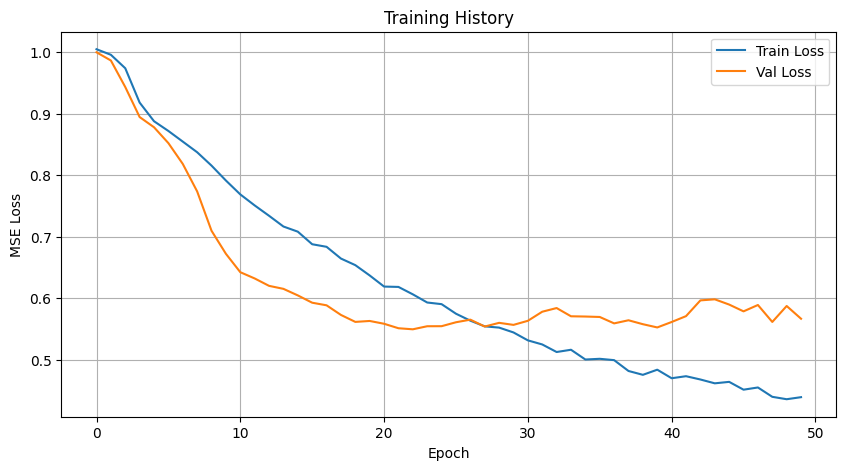

In [58]:
# Plot training history
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training History')
plt.legend()
plt.grid(True)

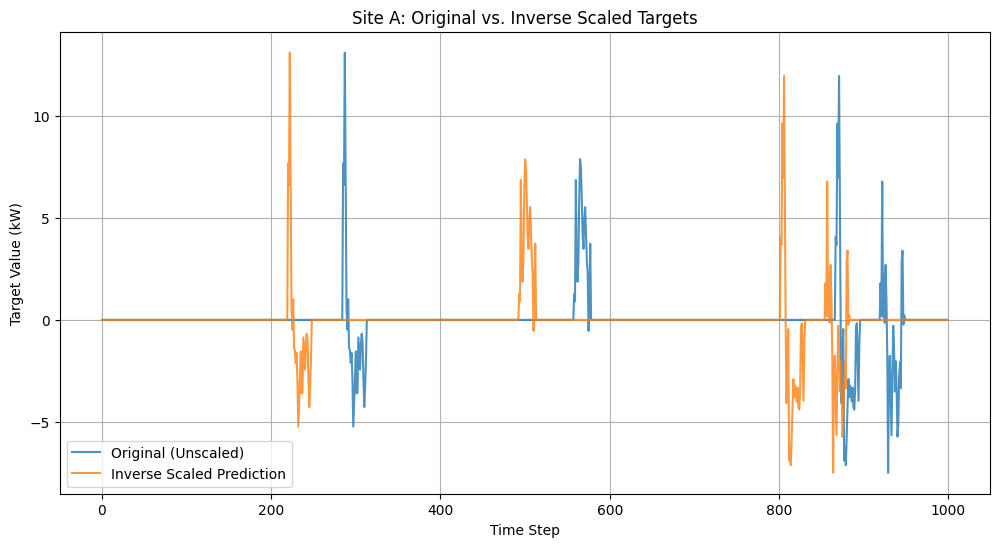

In [59]:
# np.set_printoptions(suppress=True)
# torch.set_printoptions(sci_mode=False)

plt.figure(figsize=(12, 6))
plt.plot(y_site_a_unscaled[:1000], label='Original (Unscaled)', alpha=0.8)
plt.plot(train_targets_original_inverse_scaled[:1000], label='Inverse Scaled Prediction', alpha=0.8)
plt.title("Site A: Original vs. Inverse Scaled Targets")
plt.xlabel("Time Step")
plt.ylabel("Target Value (kW)")
plt.legend()
plt.grid(True)
plt.show()

# Make predictions on validation set
model.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for X_batch, y_batch in val_loader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch)
        all_preds.append(outputs.cpu().numpy())
        all_targets.append(y_batch.numpy())

all_preds = np.concatenate(all_preds)
all_targets = np.concatenate(all_targets)

# Inverse transform predictions
preds_original = scaler_y.inverse_transform(all_preds)
targets_original = scaler_y.inverse_transform(all_targets)

# Calculate metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, f1_score

mse = mean_squared_error(targets_original, preds_original)
rmse = np.sqrt(mse)
mae = mean_absolute_error(targets_original, preds_original)
r2 = r2_score(targets_original, preds_original)

# Normalized metrics (using mean of non-zero values)
targets_nonzero = targets_original[targets_original > 0]
mean_target_nonzero = np.mean(targets_nonzero) if len(targets_nonzero) > 0 else 1.0
normalized_mae = mae / mean_target_nonzero
normalized_rmse = rmse / mean_target_nonzero

# Geometric Mean Score
geometric_mean_score = np.sqrt(mae * rmse)

# F1 Score - Calculate from validation split
# Access the validation data from your original dataframe split
# Assuming you have val_data or can recreate the validation indices
try:
    # Get the validation data indices (you need to have saved these during train/val split)
    # Method 1: If you have access to val_data dataframe
    val_dr_flags = val_dataset['Demand_Response_Flag'].values
    
    # Filter to only DR events (where capacity should be non-zero)
    dr_mask = val_dr_flags != 0
    targets_dr = targets_original[dr_mask]
    preds_dr = preds_original[dr_mask]
    
    # Binary classification: predicted capacity correctly as zero/non-zero
    targets_binary = (targets_dr > 0).astype(int)
    preds_binary = (preds_dr > 0).astype(int)
    f1_dr = f1_score(targets_binary, preds_binary)
    
    print(f"F1 Score (DR Capacity only): {f1_dr:.4f} ({f1_dr*100:.2f}%)")
except:
    # Fallback: Calculate F1 on all validation data (zero vs non-zero)
    targets_binary = (targets_original > 0).astype(int)
    preds_binary = (preds_original > 0.5).astype(int)
    f1_all = f1_score(targets_binary, preds_binary)
    print(f"F1 Score (all validation data): {f1_all:.4f} ({f1_all*100:.2f}%)")

print(f"\nValidation Metrics:")
print(f"RMSE: {rmse:.4f} kW")
print(f"MAE: {mae:.4f} kW")
print(f"Normalized MAE: {normalized_mae:.4f}")
print(f"Normalized RMSE: {normalized_rmse:.4f}")
print(f"Geometric Mean Score: {geometric_mean_score:.4f}")
print(f"R2 Score: {r2:.4f}")

# Plot predictions vs actual
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(targets_original, preds_original, alpha=0.5, s=1)
plt.plot([targets_original.min(), targets_original.max()], 
         [targets_original.min(), targets_original.max()], 'r--', lw=2)
plt.xlabel('Actual Power Consumption (kW)')
plt.ylabel('Predicted Power Consumption (kW)')
plt.title('Predictions vs Actual')
plt.grid(True)

plt.subplot(1, 2, 2)
sample_size_lower = 200
sample_size_upper = 500
plt.plot(targets_original[sample_size_lower:sample_size_upper], label='Actual', alpha=0.7)
plt.plot(preds_original[sample_size_lower:sample_size_upper], label='Predicted', alpha=0.7)
plt.xlabel('Sample')
plt.ylabel('Power Consumption (kW)')
plt.title(f'Sample Predictions (first {sample_size_upper-sample_size_lower} points)')
plt.legend()
plt.grid(True)